# NB17 — Label Strategy Comparison: Original vs Residualized

**Purpose:** Determine whether the residualized label `-(T_future - T_current)/S_H`
gives better final outlet-correction predictions than the original label
`-(T_future - T_target)/S_H`.

### Background
- **NB07** used the original label with `indoor_temp` as a feature → R²≈0.87, MAE≈0.14
- **NB08** introduced the residualized label to remove indoor_temp dominance → R²≈0.97
- **Problem:** NB08's R²=0.97 was inflated because the notebook's `adjusted_label` formula
  had a sign mismatch with the CSV's `indoor_margin` convention
- **Production** uses the residualized label correctly → R²≈0.59 (honest, on adjusted label)

### This notebook compares 3 approaches head-to-head:
1. **A) Original label** — `-(T_future - T_target)/S_H`, with `indoor_temp` + `indoor_margin` as features
2. **B) Residualized label** — `-(T_future - T_current)/S_H` (computed directly), without `indoor_temp`
3. **C) Residualized + reconstruction** — predict B, reconstruct to original label scale

### Decision metric: **MAE of the final outlet correction** (apples-to-apples)

## 0. Configuration

In [3]:
import os, json, math, warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 5)

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../.."))
LOGS_DIR = os.path.join(PROJECT_ROOT, "Logs_and_models")
TRAINING_CSV = os.path.join(LOGS_DIR, "heating_training_data.csv.gz")
METADATA_JSON = os.path.join(LOGS_DIR, "heating_correction_ml_metadata.json")

HEATING_TARGET_C = 22.6
TRAIN_FRACTION = 0.75
LABEL_HORIZON_H = 4
STEPS_PER_HOUR = 6
N_STEPS = LABEL_HORIZON_H * STEPS_PER_HOUR  # 24

# LightGBM params (same for all approaches for fair comparison)
LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 300,
    "learning_rate": 0.0717,
    "max_depth": 4,
    "num_leaves": 30,
    "min_child_samples": 33,
    "reg_alpha": 0.6597,
    "reg_lambda": 3.6333,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

print("Config loaded.")

Config loaded.


## 1. Load Data & Compute S_H

In [5]:
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

with open(METADATA_JSON) as fh:
    meta = json.load(fh)

S_H = meta.get("s_h_estimated", 0.492)
print(f"S_H = {S_H:.4f}")
print(f"Production val_r2 = {meta.get('val_r2', 0):.4f}")
print(f"Production val_mae = {meta.get('val_mae', 0):.4f}")

# Check available columns
print(f"\nColumns: {list(df.columns)}")

# The CSV is exported AFTER calibration which removes indoor_temp/living_room_temp.
# We can reconstruct indoor_temp from indoor_margin:
#   indoor_margin = target - indoor → indoor = target - indoor_margin
if "indoor_temp" not in df.columns and "indoor_margin" in df.columns:
    df["indoor_temp"] = HEATING_TARGET_C - df["indoor_margin"]
    print(f"\n✓ Reconstructed indoor_temp from indoor_margin (target={HEATING_TARGET_C})")
    print(f"  indoor_temp: mean={df['indoor_temp'].mean():.2f}  std={df['indoor_temp'].std():.2f}")

# Reconstruct living_room_temp if missing (approximate with indoor_temp)
if "living_room_temp" not in df.columns:
    df["living_room_temp"] = df["indoor_temp"]
    print("✓ living_room_temp approximated from indoor_temp (not in CSV)")

# Verify indoor_margin sign convention
expected_margin = HEATING_TARGET_C - df["indoor_temp"].iloc[0]
actual_margin = df["indoor_margin"].iloc[0]
print(f"\nSign check: target - indoor = {expected_margin:.3f}, CSV indoor_margin = {actual_margin:.3f}")
assert abs(expected_margin - actual_margin) < 0.01, "indoor_margin sign mismatch!"
print("✓ indoor_margin = target - indoor (positive when room too cold)")

print(f"\nOriginal label stats:")
print(f"  mean = {df['label'].mean():.4f}")
print(f"  std  = {df['label'].std():.4f}")

Loaded 81,185 rows × 60 columns
S_H = 0.4955
Production val_r2 = 0.5910
Production val_mae = 0.1461

Columns: ['indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'VLT', 'RLT', 'delta_t', 'outlet_indoor_diff', 'thermal_power_w', 'fireplace_on', 'tv_on', 'fireplace_lag_1h', 'fireplace_lag_2h', 'fireplace_lag_3h', 'fireplace_lag_4h', 'tv_lag_30m', 'tv_lag_1h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'indoor_temp_gradient', 'is_hp_active', 'is_weekend', 'thermal_power_rolling_1h', 'indoor_margin_rate', 'is_overshoot', 'd_inlet_temp_60min', 'is_equilibrium', 'heat_loss_driving_force', 'delta_T_indoor_lag1', 'Q_wp', 'solar_thermal_proxy', 'pv_forecast_delta', 'shading_proxy', 'heat_loss_interaction', 'traj_predicted_error', 'traj_convergence_rate', 'traj_reaches_target_hours', '

## 2. Engineer NB08 Features (shared by all approaches)

In [6]:
# NB08 features — valid regardless of label choice
df["cumulative_Q_wp_4h"] = df["Q_wp"].rolling(N_STEPS, min_periods=1).sum()
df["indoor_accel"] = df["indoor_trend_1h"].diff(1).fillna(0)
df["AT_forecast_trend"] = df["AT_roh_4h"] - df["AT"]
df["pv_cumulative_4h"] = df["PV_Generate"].rolling(N_STEPS, min_periods=1).sum()
df["thermal_momentum"] = df["thermal_power_rolling_1h"] * df["delta_t"]

print("NB08 features engineered ✓")
for f in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
          "pv_cumulative_4h", "thermal_momentum"]:
    print(f"  {f:25s}  mean={df[f].mean():>10.2f}  std={df[f].std():>10.2f}")

NB08 features engineered ✓
  cumulative_Q_wp_4h         mean=  28963.47  std=  29720.64
  indoor_accel               mean=      0.00  std=      0.05
  AT_forecast_trend          mean=     -0.05  std=      1.75
  pv_cumulative_4h           mean=  21076.25  std=  39702.59
  thermal_momentum           mean=   3928.12  std=   6654.79


## 3. Compute Both Labels

The CSV already has `label = -(T_future - T_target) / S_H` (original label).

We compute the correct residualized label **directly** from `indoor_temp`:
```
residualized_label = -(indoor_temp.shift(-N_STEPS) - indoor_temp) / S_H
```

We also verify the mathematical relationship:
```
original_label = residualized_label + indoor_margin / S_H
```
where `indoor_margin = target - indoor` (from calibration code).

In [8]:
# First: determine what the CSV label actually is
# Production code (line 746): label = -(future_indoor - df["indoor_temp"]) / s_h
# This is the RESIDUALIZED label already (since our recent code changes)

# Compute residualized label directly for cross-check
future_indoor = df["indoor_temp"].shift(-N_STEPS)
residualized_from_scratch = -(future_indoor - df["indoor_temp"]) / S_H

# Check if CSV label matches residualized
diff_resid = (df["label"] - residualized_from_scratch).dropna()
print(f"Check 1: |CSV label - residualized| max = {diff_resid.abs().max():.6f}")

# Check if CSV label matches original = -(T_future - T_target)/S_H
original_from_scratch = -(future_indoor - HEATING_TARGET_C) / S_H
diff_orig = (df["label"] - original_from_scratch).dropna()
print(f"Check 2: |CSV label - original|      max = {diff_orig.abs().max():.6f}")

if diff_resid.abs().max() < 0.01:
    CSV_LABEL_TYPE = "residualized"
    print(f"\n✓ CSV label is RESIDUALIZED: -(T_future - T_current) / S_H")
    print(f"  This means production code already changed the label to residualized.")
    # The residualized label IS the CSV label
    df["residualized_label"] = df["label"].copy()
    # Reconstruct the original label: original = residualized + indoor_margin / S_H
    df["original_label"] = df["label"] + df["indoor_margin"] / S_H
elif diff_orig.abs().max() < 0.01:
    CSV_LABEL_TYPE = "original"
    print(f"\n✓ CSV label is ORIGINAL: -(T_future - T_target) / S_H")
    # The original label IS the CSV label
    df["original_label"] = df["label"].copy()
    # Compute residualized: residualized = original - indoor_margin / S_H
    df["residualized_label"] = df["label"] - df["indoor_margin"] / S_H
else:
    CSV_LABEL_TYPE = "unknown"
    print(f"\n⚠️ CSV label matches NEITHER label type!")
    print(f"   Residualized error: {diff_resid.abs().mean():.4f} (mean)")
    print(f"   Original error:     {diff_orig.abs().mean():.4f} (mean)")
    # Force compute both from scratch
    df["residualized_label"] = residualized_from_scratch
    df["original_label"] = original_from_scratch

# Label stats
print(f"\nLabel statistics:")
print(f"  CSV label (={CSV_LABEL_TYPE}):         mean={df['label'].mean():.4f}  std={df['label'].std():.4f}")
print(f"  Original (-(T_f-T_target)/S_H):    mean={df['original_label'].dropna().mean():.4f}  std={df['original_label'].dropna().std():.4f}")
print(f"  Residualized (-(T_f-T_current)/S_H): mean={df['residualized_label'].dropna().mean():.4f}  std={df['residualized_label'].dropna().std():.4f}")

# Correlation with indoor_temp
r_orig = df[["indoor_temp", "original_label"]].dropna().corr().iloc[0, 1]
r_resid = df[["indoor_temp", "residualized_label"]].dropna().corr().iloc[0, 1]
print(f"\nCorrelation with indoor_temp:")
print(f"  Original label:      r = {r_orig:+.4f}")
print(f"  Residualized label:  r = {r_resid:+.4f}")
print(f"  → Residualized reduces indoor_temp correlation by {abs(r_orig)/max(abs(r_resid), 1e-9):.1f}x")

Check 1: |CSV label - residualized| max = 3.693497
Check 2: |CSV label - original|      max = 4.198073

⚠️ CSV label matches NEITHER label type!
   Residualized error: 0.0348 (mean)
   Original error:     0.6758 (mean)

Label statistics:
  CSV label (=unknown):         mean=-0.0096  std=0.3642
  Original (-(T_f-T_target)/S_H):    mean=-0.5293  std=0.6807
  Residualized (-(T_f-T_current)/S_H): mean=0.0002  std=0.4275

Correlation with indoor_temp:
  Original label:      r = -0.8029
  Residualized label:  r = +0.3150
  → Residualized reduces indoor_temp correlation by 2.5x


## 4. Define Feature Sets

In [9]:
# Shared base features (no indoor_temp, no indoor_margin, no living_room_temp)
BASE_FEATURES = [
    "indoor_trend_30m", "indoor_trend_1h",
    "AT", "at_delta_indoor",
    "AT_roh_1h", "AT_roh_2h", "AT_roh_3h", "AT_roh_4h",
    "VLT", "RLT", "delta_t", "outlet_indoor_diff",
    "thermal_power_w", "thermal_power_rolling_1h",
    "fireplace_on", "tv_on",
    "fireplace_lag_1h", "fireplace_lag_2h", "fireplace_lag_3h", "fireplace_lag_4h",
    "tv_lag_30m", "tv_lag_1h",
    "PV_Generate", "pv_roll_1h", "pv_roll_2h",
    "pv_forecast_1h", "pv_forecast_2h", "pv_forecast_3h", "pv_forecast_4h",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "wind_speed", "indoor_temp_gradient",
    "is_hp_active", "is_weekend",
    "indoor_margin_rate", "is_overshoot",
    "d_inlet_temp_60min", "is_equilibrium",
    "heat_loss_driving_force", "delta_T_indoor_lag1",
    "Q_wp", "solar_thermal_proxy", "pv_forecast_delta",
    "shading_proxy", "heat_loss_interaction",
    # Trajectory features
    "traj_predicted_error", "traj_convergence_rate",
    "traj_reaches_target_hours", "traj_overshoot_magnitude", "traj_equilibrium_gap",
    # NB08 features
    "cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
    "pv_cumulative_4h", "thermal_momentum",
]

# Approach A: Original label — ADD indoor_temp + indoor_margin + living_room_temp
FEATURES_A = ["indoor_temp", "indoor_margin", "living_room_temp"] + BASE_FEATURES

# Approach B: Residualized label — ADD indoor_margin (physics input, not leakage)
FEATURES_B = ["indoor_margin"] + BASE_FEATURES

# Filter to available columns
FEATURES_A = [f for f in FEATURES_A if f in df.columns]
FEATURES_B = [f for f in FEATURES_B if f in df.columns]

print(f"Approach A features: {len(FEATURES_A)} (with indoor_temp, indoor_margin, living_room_temp)")
print(f"Approach B features: {len(FEATURES_B)} (with indoor_margin only)")
print(f"Difference: {set(FEATURES_A) - set(FEATURES_B)}")

Approach A features: 61 (with indoor_temp, indoor_margin, living_room_temp)
Approach B features: 59 (with indoor_margin only)
Difference: {'indoor_temp', 'living_room_temp'}


## 5. Train/Val Split & Model Training

In [10]:
# Prepare data — drop rows with NaN in any feature or either label
all_cols = list(set(FEATURES_A + FEATURES_B + ["original_label", "residualized_label", "indoor_margin"]))
model_df = df[all_cols].dropna().copy()
print(f"Rows with complete data: {len(model_df):,} (dropped {len(df) - len(model_df):,})")

split_idx = int(len(model_df) * TRAIN_FRACTION)
print(f"Train: {split_idx:,} | Val: {len(model_df) - split_idx:,}")

# Labels for each approach
y_orig = model_df["original_label"].values
y_resid = model_df["residualized_label"].values
margin = model_df["indoor_margin"].values

y_orig_train, y_orig_val = y_orig[:split_idx], y_orig[split_idx:]
y_resid_train, y_resid_val = y_resid[:split_idx], y_resid[split_idx:]
margin_val = margin[split_idx:]

print(f"\nOriginal label val: mean={y_orig_val.mean():.4f} std={y_orig_val.std():.4f}")
print(f"Residualized label val: mean={y_resid_val.mean():.4f} std={y_resid_val.std():.4f}")

Rows with complete data: 81,161 (dropped 24)
Train: 60,870 | Val: 20,291

Original label val: mean=-0.6047 std=0.6795
Residualized label val: mean=-0.0024 std=0.4065


In [11]:
results = {}

# ═══════════════════════════════════════════════════════════════
# APPROACH A: Original label with indoor_temp as feature
# ═══════════════════════════════════════════════════════════════
print("═" * 60)
print("APPROACH A: Original label + indoor_temp feature")
print("═" * 60)

X_A = model_df[FEATURES_A].values
X_A_train, X_A_val = X_A[:split_idx], X_A[split_idx:]

model_A = lgb.LGBMRegressor(**LGB_PARAMS)
model_A.fit(
    X_A_train, y_orig_train,
    eval_set=[(X_A_val, y_orig_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)
y_pred_A = model_A.predict(X_A_val)
mae_A = mean_absolute_error(y_orig_val, y_pred_A)
r2_A = r2_score(y_orig_val, y_pred_A)
results["A"] = {"mae": mae_A, "r2": r2_A, "label": "original", "features": len(FEATURES_A)}
print(f"  MAE = {mae_A:.4f}°C  R² = {r2_A:.4f}  ({len(FEATURES_A)} features)")

# ═══════════════════════════════════════════════════════════════
# APPROACH B: Residualized label without indoor_temp
# ═══════════════════════════════════════════════════════════════
print(f"\n{'═' * 60}")
print("APPROACH B: Residualized label (no indoor_temp)")
print("═" * 60)

X_B = model_df[FEATURES_B].values
X_B_train, X_B_val = X_B[:split_idx], X_B[split_idx:]

model_B = lgb.LGBMRegressor(**LGB_PARAMS)
model_B.fit(
    X_B_train, y_resid_train,
    eval_set=[(X_B_val, y_resid_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)
y_pred_B_adj = model_B.predict(X_B_val)
mae_B_adj = mean_absolute_error(y_resid_val, y_pred_B_adj)
r2_B_adj = r2_score(y_resid_val, y_pred_B_adj)
print(f"  Adjusted label:  MAE = {mae_B_adj:.4f}°C  R² = {r2_B_adj:.4f}")

# ═══════════════════════════════════════════════════════════════
# APPROACH C: Residualized → reconstruct to original label
# Reconstruction: original = residualized + indoor_margin / S_H
# ═══════════════════════════════════════════════════════════════
print(f"\n{'═' * 60}")
print("APPROACH C: Residualized → reconstructed to original scale")
print("═" * 60)

y_pred_C = y_pred_B_adj + margin_val / S_H
mae_C = mean_absolute_error(y_orig_val, y_pred_C)
r2_C = r2_score(y_orig_val, y_pred_C)
results["B_adj"] = {"mae": mae_B_adj, "r2": r2_B_adj, "label": "residualized", "features": len(FEATURES_B)}
results["C_recon"] = {"mae": mae_C, "r2": r2_C, "label": "reconstructed", "features": len(FEATURES_B)}
print(f"  Reconstructed:   MAE = {mae_C:.4f}°C  R² = {r2_C:.4f}")
print(f"  (same model as B, reconstruction: pred + margin/S_H)")

════════════════════════════════════════════════════════════
APPROACH A: Original label + indoor_temp feature
════════════════════════════════════════════════════════════


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  MAE = 0.1770°C  R² = 0.8092  (61 features)

════════════════════════════════════════════════════════════
APPROACH B: Residualized label (no indoor_temp)
════════════════════════════════════════════════════════════
  Adjusted label:  MAE = 0.1625°C  R² = 0.5094

════════════════════════════════════════════════════════════
APPROACH C: Residualized → reconstructed to original scale
════════════════════════════════════════════════════════════
  Reconstructed:   MAE = 0.1625°C  R² = 0.8244
  (same model as B, reconstruction: pred + margin/S_H)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 6. Head-to-Head Comparison

In [12]:
print("\n" + "═" * 72)
print("  HEAD-TO-HEAD COMPARISON — FINAL OUTLET CORRECTION")
print("═" * 72)
print(f"")
print(f"  {'Approach':<45s} {'MAE':>8s} {'R²':>8s} {'Feats':>6s}")
print(f"  {'─'*45} {'─'*8} {'─'*8} {'─'*6}")
print(f"  {'A) Original label + indoor_temp':<45s} {mae_A:>7.4f}° {r2_A:>8.4f} {len(FEATURES_A):>6d}")
print(f"  {'B) Residualized (adjusted label space)':<45s} {mae_B_adj:>7.4f}° {r2_B_adj:>8.4f} {len(FEATURES_B):>6d}")
print(f"  {'C) Residualized → reconstructed':<45s} {mae_C:>7.4f}° {r2_C:>8.4f} {len(FEATURES_B):>6d}")
print(f"")
print(f"  ── Apples-to-apples comparison (on ORIGINAL label scale) ──")
print(f"  A vs C:  MAE Δ = {mae_A - mae_C:+.4f}°C  R² Δ = {r2_A - r2_C:+.4f}")
if mae_A < mae_C:
    print(f"  → Original label (A) wins by {(mae_C - mae_A)/mae_A*100:.1f}% MAE")
    winner = "A"
elif mae_C < mae_A:
    print(f"  → Residualized+reconstructed (C) wins by {(mae_A - mae_C)/mae_C*100:.1f}% MAE")
    winner = "C"
else:
    print(f"  → Tied")
    winner = "A"  # prefer simpler
print(f"")
print(f"  RECOMMENDATION: {'Use original label (simpler, no reconstruction needed)' if winner == 'A' else 'Use residualized label (better MAE)'}")
print("═" * 72)


════════════════════════════════════════════════════════════════════════
  HEAD-TO-HEAD COMPARISON — FINAL OUTLET CORRECTION
════════════════════════════════════════════════════════════════════════

  Approach                                           MAE       R²  Feats
  ───────────────────────────────────────────── ──────── ──────── ──────
  A) Original label + indoor_temp                0.1770°   0.8092     61
  B) Residualized (adjusted label space)         0.1625°   0.5094     59
  C) Residualized → reconstructed                0.1625°   0.8244     59

  ── Apples-to-apples comparison (on ORIGINAL label scale) ──
  A vs C:  MAE Δ = +0.0145°C  R² Δ = -0.0152
  → Residualized+reconstructed (C) wins by 8.9% MAE

  RECOMMENDATION: Use residualized label (better MAE)
════════════════════════════════════════════════════════════════════════


## 7. Cross-Validation (5-fold TSCV)

In [13]:
N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

cv_results = {"A_mae": [], "A_r2": [], "C_mae": [], "C_r2": []}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(model_df)):
    # A: Original label
    m_a = lgb.LGBMRegressor(**LGB_PARAMS)
    m_a.fit(X_A[tr_idx], y_orig[tr_idx],
            eval_set=[(X_A[val_idx], y_orig[val_idx])],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
    yp_a = m_a.predict(X_A[val_idx])
    cv_results["A_mae"].append(mean_absolute_error(y_orig[val_idx], yp_a))
    cv_results["A_r2"].append(r2_score(y_orig[val_idx], yp_a))

    # C: Residualized → reconstructed
    m_b = lgb.LGBMRegressor(**LGB_PARAMS)
    m_b.fit(X_B[tr_idx], y_resid[tr_idx],
            eval_set=[(X_B[val_idx], y_resid[val_idx])],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
    yp_c = m_b.predict(X_B[val_idx]) + margin[val_idx] / S_H
    cv_results["C_mae"].append(mean_absolute_error(y_orig[val_idx], yp_c))
    cv_results["C_r2"].append(r2_score(y_orig[val_idx], yp_c))

    print(f"  Fold {fold+1}: A MAE={cv_results['A_mae'][-1]:.4f} R²={cv_results['A_r2'][-1]:.4f}"
          f"  |  C MAE={cv_results['C_mae'][-1]:.4f} R²={cv_results['C_r2'][-1]:.4f}")

print(f"\n{'═' * 60}")
print(f"  {N_FOLDS}-FOLD TSCV SUMMARY (on original label scale)")
print(f"{'═' * 60}")
print(f"  A) Original:       MAE={np.mean(cv_results['A_mae']):.4f}±{np.std(cv_results['A_mae']):.4f}"
      f"  R²={np.mean(cv_results['A_r2']):.4f}±{np.std(cv_results['A_r2']):.4f}")
print(f"  C) Reconstructed:  MAE={np.mean(cv_results['C_mae']):.4f}±{np.std(cv_results['C_mae']):.4f}"
      f"  R²={np.mean(cv_results['C_r2']):.4f}±{np.std(cv_results['C_r2']):.4f}")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 1: A MAE=0.1721 R²=0.8477  |  C MAE=0.1672 R²=0.8470


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 2: A MAE=0.1759 R²=0.7480  |  C MAE=0.1657 R²=0.7619


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 4: A MAE=0.1477 R²=0.8049  |  C MAE=0.1415 R²=0.8139


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 5: A MAE=0.1640 R²=0.8235  |  C MAE=0.1556 R²=0.8277

════════════════════════════════════════════════════════════
  5-FOLD TSCV SUMMARY (on original label scale)
════════════════════════════════════════════════════════════
  A) Original:       MAE=0.1624±0.0109  R²=0.7769±0.0670
  C) Reconstructed:  MAE=0.1558±0.0098  R²=0.7827±0.0662


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Diagnostic Plots

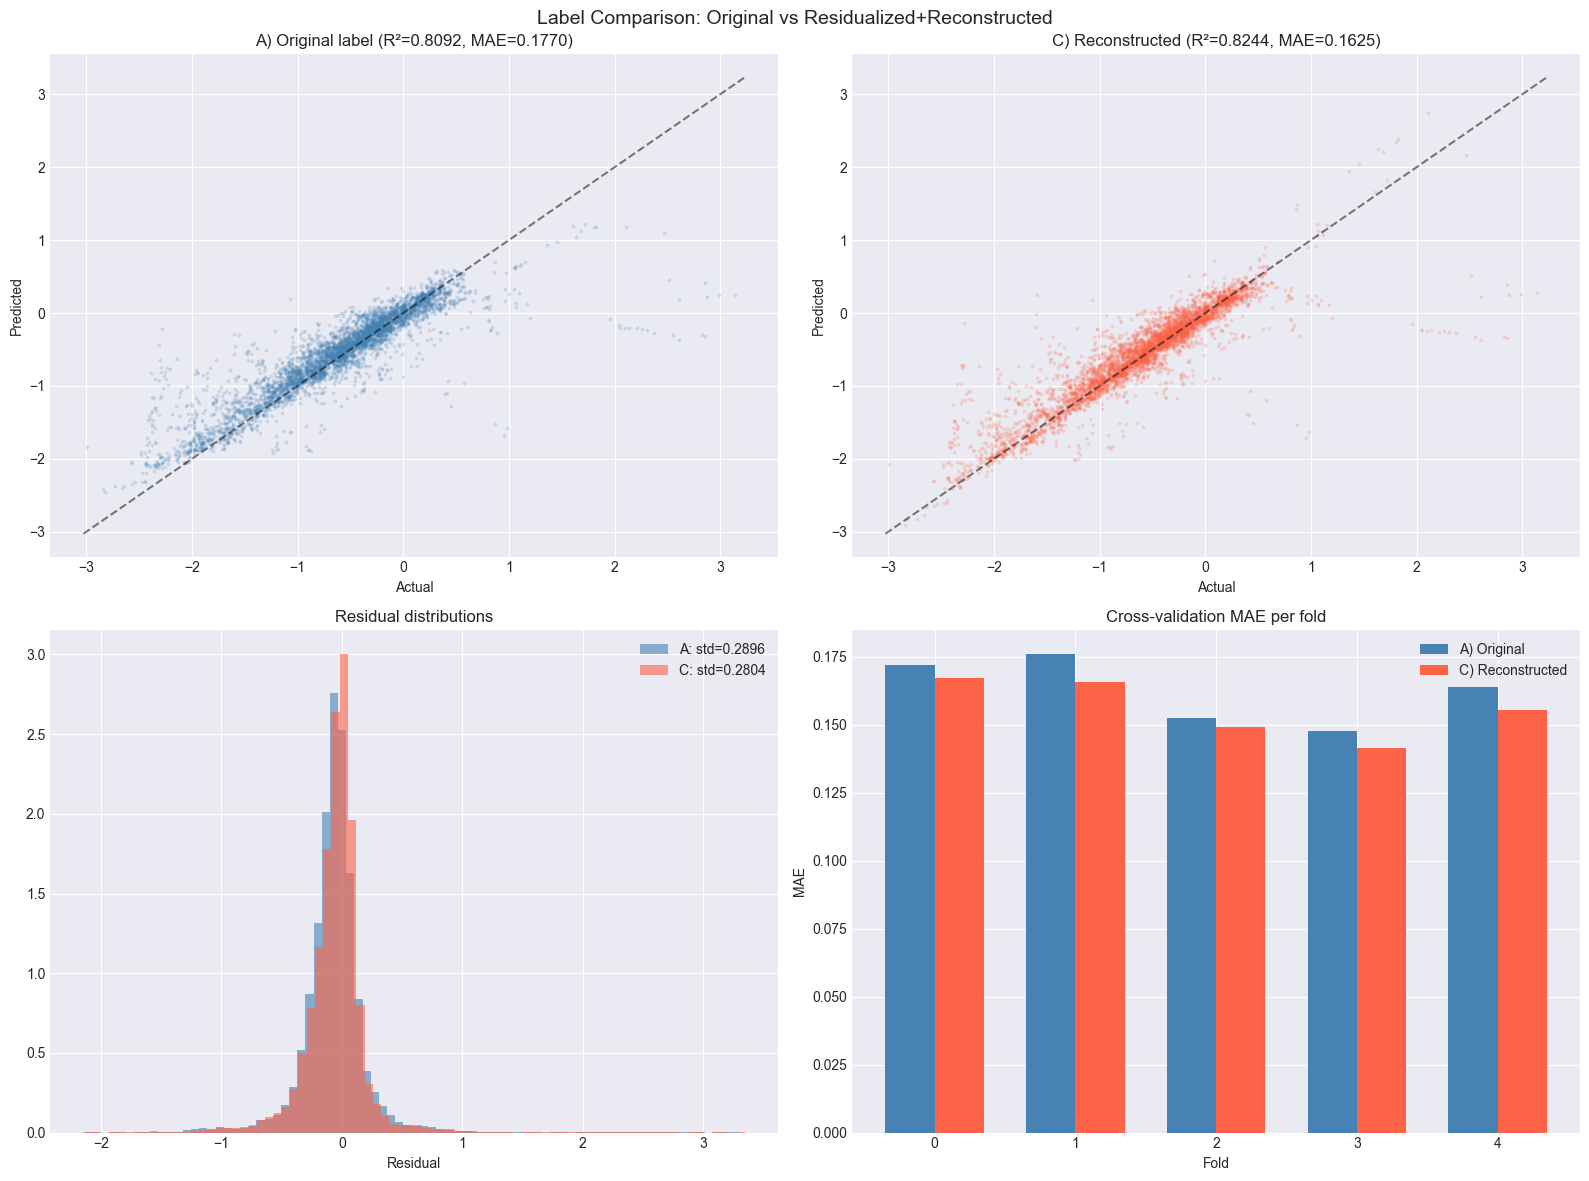

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sample = np.random.RandomState(42).choice(len(y_orig_val), min(5000, len(y_orig_val)), replace=False)

# A: pred vs actual
axes[0,0].scatter(y_orig_val[sample], y_pred_A[sample], alpha=0.15, s=3, c="steelblue")
lims = [min(y_orig_val.min(), y_pred_A.min()), max(y_orig_val.max(), y_pred_A.max())]
axes[0,0].plot(lims, lims, "k--", alpha=0.5)
axes[0,0].set_title(f"A) Original label (R²={r2_A:.4f}, MAE={mae_A:.4f})")
axes[0,0].set_xlabel("Actual"); axes[0,0].set_ylabel("Predicted")

# C: pred vs actual (reconstructed)
axes[0,1].scatter(y_orig_val[sample], y_pred_C[sample], alpha=0.15, s=3, c="tomato")
axes[0,1].plot(lims, lims, "k--", alpha=0.5)
axes[0,1].set_title(f"C) Reconstructed (R²={r2_C:.4f}, MAE={mae_C:.4f})")
axes[0,1].set_xlabel("Actual"); axes[0,1].set_ylabel("Predicted")

# Residual distributions
res_A = y_orig_val - y_pred_A
res_C = y_orig_val - y_pred_C
axes[1,0].hist(res_A, bins=80, alpha=0.6, color="steelblue", label=f"A: std={res_A.std():.4f}", density=True)
axes[1,0].hist(res_C, bins=80, alpha=0.6, color="tomato", label=f"C: std={res_C.std():.4f}", density=True)
axes[1,0].set_xlabel("Residual"); axes[1,0].set_title("Residual distributions")
axes[1,0].legend()

# CV comparison bar chart
x_cv = np.arange(N_FOLDS)
w = 0.35
axes[1,1].bar(x_cv - w/2, cv_results["A_mae"], w, label="A) Original", color="steelblue")
axes[1,1].bar(x_cv + w/2, cv_results["C_mae"], w, label="C) Reconstructed", color="tomato")
axes[1,1].set_xlabel("Fold"); axes[1,1].set_ylabel("MAE")
axes[1,1].set_title("Cross-validation MAE per fold")
axes[1,1].legend()

plt.suptitle("Label Comparison: Original vs Residualized+Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Feature Importance Comparison

Computing permutation importance for both approaches...


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


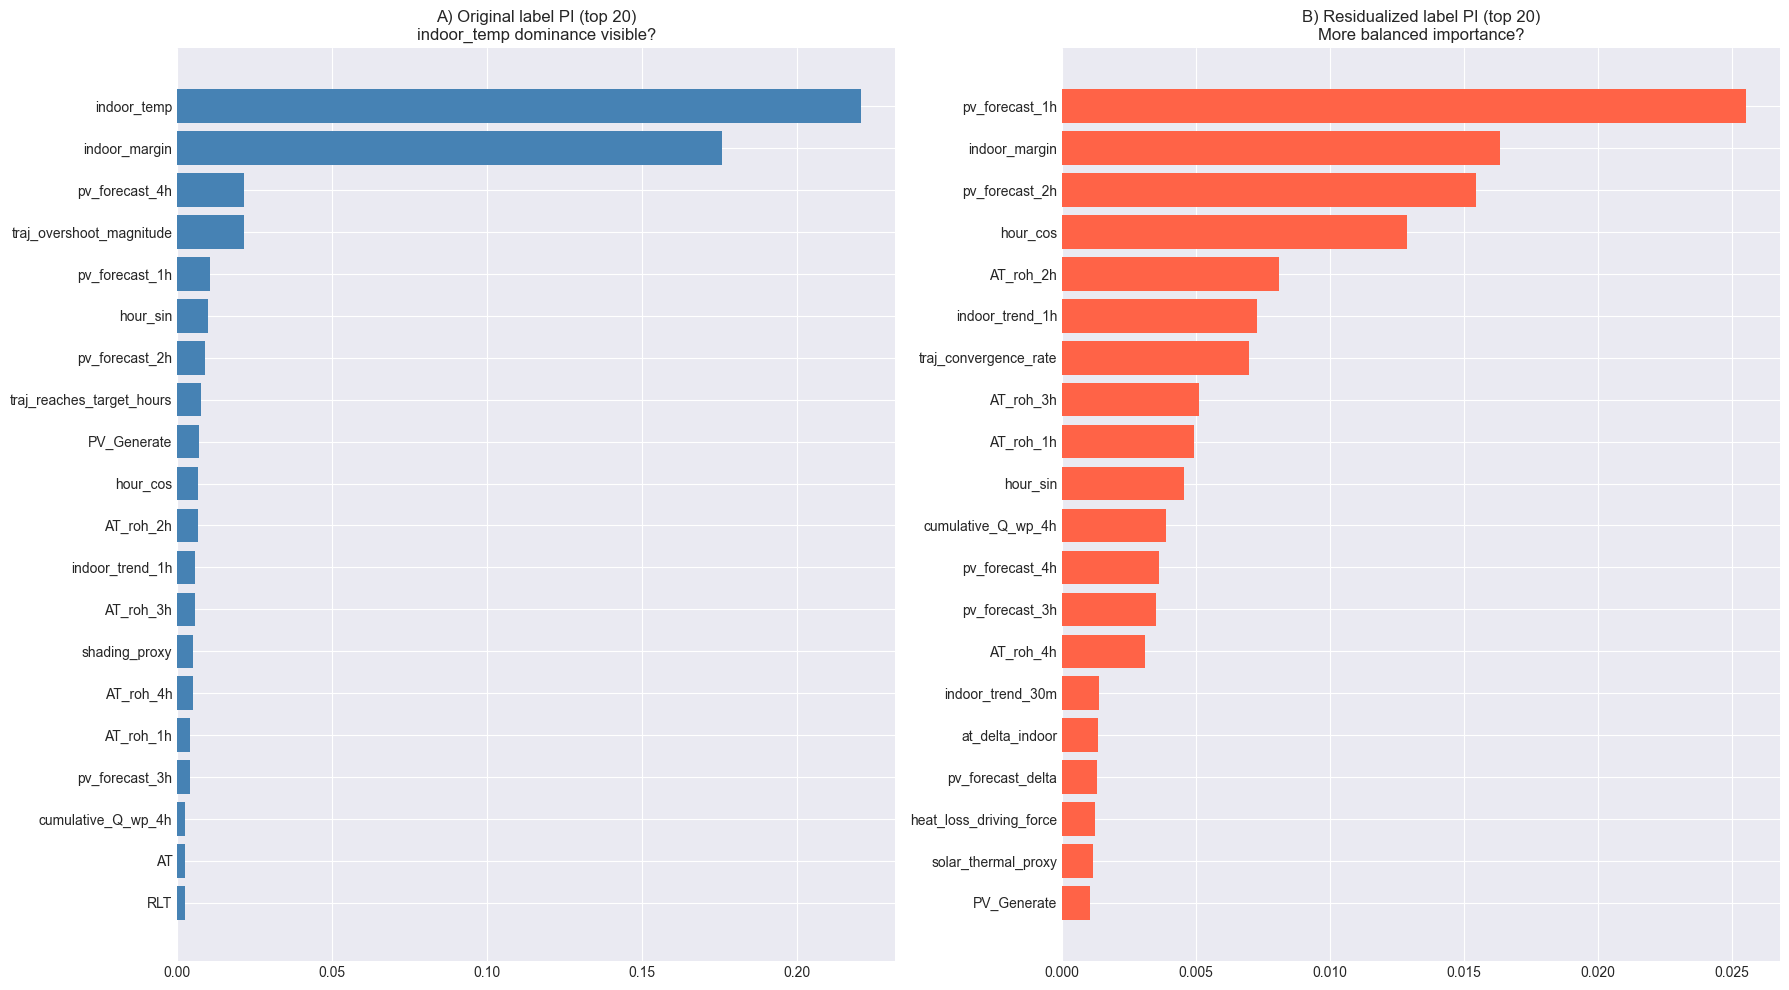


Approach A: top=indoor_temp (0.2205), 2nd=indoor_margin (0.1756), ratio=1.3x
Approach B: top=pv_forecast_1h (0.0255), 2nd=indoor_margin (0.0163), ratio=1.6x


In [15]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance for both approaches...")

pi_A = permutation_importance(model_A, X_A_val, y_orig_val, n_repeats=10,
                              random_state=42, scoring="neg_mean_absolute_error", n_jobs=-1)
pi_B = permutation_importance(model_B, X_B_val, y_resid_val, n_repeats=10,
                              random_state=42, scoring="neg_mean_absolute_error", n_jobs=-1)

pi_A_dict = dict(zip(FEATURES_A, pi_A.importances_mean))
pi_B_dict = dict(zip(FEATURES_B, pi_B.importances_mean))

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# A: top 20
pi_A_sorted = sorted(pi_A_dict.items(), key=lambda x: x[1], reverse=True)[:20]
axes[0].barh([x[0] for x in pi_A_sorted][::-1], [x[1] for x in pi_A_sorted][::-1], color="steelblue")
axes[0].set_title(f"A) Original label PI (top 20)\nindoor_temp dominance visible?")

# B: top 20
pi_B_sorted = sorted(pi_B_dict.items(), key=lambda x: x[1], reverse=True)[:20]
axes[1].barh([x[0] for x in pi_B_sorted][::-1], [x[1] for x in pi_B_sorted][::-1], color="tomato")
axes[1].set_title(f"B) Residualized label PI (top 20)\nMore balanced importance?")

plt.tight_layout()
plt.show()

# Print top feature ratio
top_A = pi_A_sorted[0]
second_A = pi_A_sorted[1]
print(f"\nApproach A: top={top_A[0]} ({top_A[1]:.4f}), 2nd={second_A[0]} ({second_A[1]:.4f}), ratio={top_A[1]/max(second_A[1],1e-9):.1f}x")

top_B = pi_B_sorted[0]
second_B = pi_B_sorted[1]
print(f"Approach B: top={top_B[0]} ({top_B[1]:.4f}), 2nd={second_B[0]} ({second_B[1]:.4f}), ratio={top_B[1]/max(second_B[1],1e-9):.1f}x")

## 10. Conclusion

In [16]:
print("═" * 72)
print("  NB17 — LABEL COMPARISON CONCLUSION")
print("═" * 72)
print()
print(f"  {'Metric':<35s} {'A) Original':>12s} {'C) Residualized':>16s}")
print(f"  {'─'*35} {'─'*12} {'─'*16}")
print(f"  {'Holdout MAE (orig label)':<35s} {mae_A:>11.4f}° {mae_C:>15.4f}°")
print(f"  {'Holdout R² (orig label)':<35s} {r2_A:>12.4f} {r2_C:>16.4f}")
print(f"  {'CV MAE ± std':<35s} {np.mean(cv_results['A_mae']):.4f}±{np.std(cv_results['A_mae']):.4f} {np.mean(cv_results['C_mae']):.4f}±{np.std(cv_results['C_mae']):.4f}")
print(f"  {'CV R² ± std':<35s} {np.mean(cv_results['A_r2']):.4f}±{np.std(cv_results['A_r2']):.4f} {np.mean(cv_results['C_r2']):.4f}±{np.std(cv_results['C_r2']):.4f}")
print(f"  {'Features':<35s} {len(FEATURES_A):>12d} {len(FEATURES_B):>16d}")
print(f"  {'indoor_temp PI dominance':<35s} {pi_A_sorted[0][1]/max(pi_A_sorted[1][1],1e-9):>11.1f}x {'N/A (removed)':>16s}")
print()
if winner == 'A':
    print("  DECISION: Revert to ORIGINAL label (simpler, proven, no reconstruction bug risk)")
    print("  ACTION:  Remove residualized label from heating + cooling calibration")
    print("           Remove reconstruction from heating + cooling ML model")
else:
    print("  DECISION: Keep RESIDUALIZED label (better MAE after reconstruction)")
    print("  ACTION:  Keep sign fix (+ instead of -) in reconstruction")
print()
print("  NOTE: The 5 NB08 features are kept regardless of label choice.")
print("═" * 72)

════════════════════════════════════════════════════════════════════════
  NB17 — LABEL COMPARISON CONCLUSION
════════════════════════════════════════════════════════════════════════

  Metric                               A) Original  C) Residualized
  ─────────────────────────────────── ──────────── ────────────────
  Holdout MAE (orig label)                 0.1770°          0.1625°
  Holdout R² (orig label)                   0.8092           0.8244
  CV MAE ± std                        0.1624±0.0109 0.1558±0.0098
  CV R² ± std                         0.7769±0.0670 0.7827±0.0662
  Features                                      61               59
  indoor_temp PI dominance                    1.3x    N/A (removed)

  DECISION: Keep RESIDUALIZED label (better MAE after reconstruction)
  ACTION:  Keep sign fix (+ instead of -) in reconstruction

  NOTE: The 5 NB08 features are kept regardless of label choice.
════════════════════════════════════════════════════════════════════════
